In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
from scipy.signal import correlate, butter, filtfilt
from matplotlib.ticker import LogLocator
import usefulfunc as uf
import re
from matplotlib.colors import TwoSlopeNorm

In [2]:
plt.rcParams.update({
    'font.size': 24,
    'axes.labelsize': 28,
    'axes.titlesize': 30,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
})

We want to calculate the anomaly fields for certain years. The process will include creating a function for calculating it and then testing it on certain years. Once we have verified the anomaly datasets, we can proceed with the rest of the years. First, we will create an anomaly function. In addition, we'll also make sure to interpolate the leap years again. 

In [3]:
annual_cycle = xr.open_mfdataset('zmzdaily_annual_cycle.nc')

In [4]:
zmzanncyc = annual_cycle.Z

In [5]:
zmzanncyc 

<xarray.DataArray 'Z' (level: 37, time: 365, latitude: 721)> Size: 78MB
dask.array<open_dataset-Z, shape=(37, 365, 721), dtype=float64, chunksize=(37, 365, 721), chunktype=numpy.ndarray>
Coordinates:
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0

In [6]:
zmz2005 = xr.open_mfdataset('Z_zonal_means/zmzdaily2005.nc').Z

In [7]:
zmz2005

<xarray.DataArray 'Z' (level: 37, time: 365, latitude: 721)> Size: 39MB
dask.array<open_dataset-Z, shape=(37, 365, 721), dtype=float32, chunksize=(37, 365, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) datetime64[ns] 3kB 2005-01-01 2005-01-02 ... 2005-12-31

In [6]:
# For the interpolation function, call it via uf.interpleapyear(). It accepts the arguments of (data, year)
# Anomaly function, accepts arguments for (annual_cycle, year_dataset). Annual cycle is a DataArray, while the 
# year_dataset is a filename.
def extract_year(filename):
    match = re.search(r'\d{4}', filename)
    return match.group() if match else None

def calcanomaly(yeardata):
    anncyc = xr.open_mfdataset('zmzdaily_annual_cycle.nc').Z
    yearstr = extract_year(yeardata)
    yearda = xr.open_mfdataset(yeardata).Z
    cheese = np.arange(1,366)
    if yearda.shape[1] == 366:
        interped = uf.interpleapyear(yearda, yearstr).assign_coords({'time': cheese})
    else:
        cheese = np.arange(1,366)
        interped = yearda.assign_coords({'time': cheese})

    anomalyda = interped - anncyc # Need to verify that the shapes of both are consistent
    return anomalyda



In [24]:
zmzdaily2020anom = calcanomaly('Z_zonal_means/zmzdaily2020.nc')

2020 is a leap year!


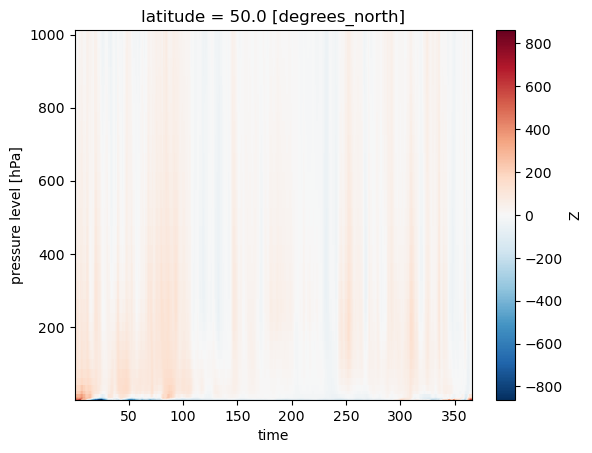

In [41]:
zmzdaily2020anom.sel(latitude = 50).plot()

Results make sense...let's try for other years. Maybe a year with record SSWEs? Super anomalous NAO/AO? 2010 and 2018 are two years that come immediately to mind.

In [6]:
zmzdaily2010anom = calcanomaly('Z_zonal_means/zmzdaily2010.nc')

In [7]:
zmzdaily2010anom

<xarray.DataArray 'Z' (level: 37, time: 365, latitude: 721)> Size: 78MB
dask.array<sub, shape=(37, 365, 721), dtype=float64, chunksize=(37, 365, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

I chose latitude = 65 as that is where Iceland/Greenland is located. Also I should expect to see very positive anomalies there during -NAO events. Two come to mind, one in Jan 2010 winter (2009-10 winter) and one in Dec 2010 (2010-11 winter).

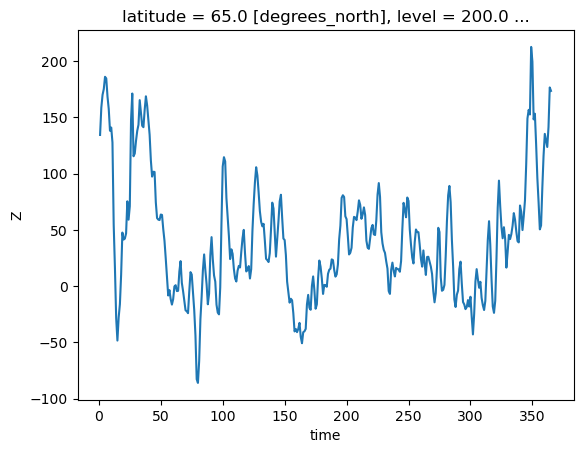

In [8]:
zmzdaily2010anom.sel(latitude = 65, level = 200).plot()

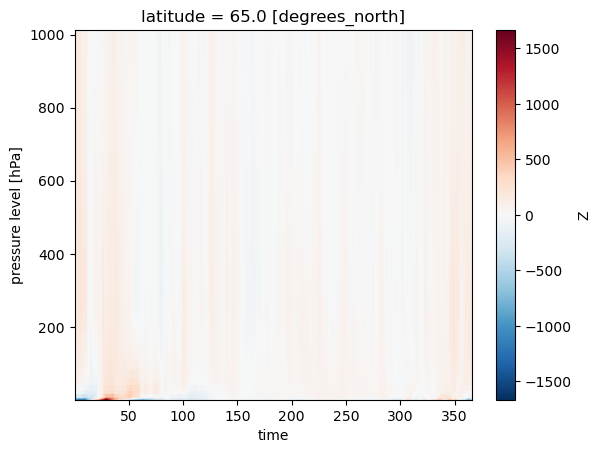

In [9]:
zmzdaily2010anom.sel(latitude = 65).plot()

Let's calculate the anomaly fields for the rest of the years..

In [7]:
for year in range(1979, 2024):
    anomalies = calcanomaly(f'Z_zonal_means/zmzdaily{year}.nc')
    anomalies.to_netcdf(f'zmz_anomalies/zmzdailyanom{year}.nc')
    print(f'Daily zonal mean anomaly completed for {year}')

Daily zonal mean anomaly completed for 1979
1980 is a leap year!
Daily zonal mean anomaly completed for 1980
Daily zonal mean anomaly completed for 1981
Daily zonal mean anomaly completed for 1982
Daily zonal mean anomaly completed for 1983
1984 is a leap year!
Daily zonal mean anomaly completed for 1984
Daily zonal mean anomaly completed for 1985
Daily zonal mean anomaly completed for 1986
Daily zonal mean anomaly completed for 1987
1988 is a leap year!
Daily zonal mean anomaly completed for 1988
Daily zonal mean anomaly completed for 1989
Daily zonal mean anomaly completed for 1990
Daily zonal mean anomaly completed for 1991
1992 is a leap year!
Daily zonal mean anomaly completed for 1992
Daily zonal mean anomaly completed for 1993
Daily zonal mean anomaly completed for 1994
Daily zonal mean anomaly completed for 1995
1996 is a leap year!
Daily zonal mean anomaly completed for 1996
Daily zonal mean anomaly completed for 1997
Daily zonal mean anomaly completed for 1998
Daily zonal mea

The anomaly fields for daily zonal mean of GPH are found in the folder zmz_anomalies

Now we want to analyze the variance of these anomalies. 

# Variance of daily zonal mean anomalies of Z
# Plus cross-correlation of $\bar{Z}(p)$ with $\bar{Z}(850)$ at the equator.

In [3]:
zmzdanoms = []
for year in range(1979, 2024):
    ds = xr.open_mfdataset(f'zmz_anomalies/zmzdailyanom{year}.nc')
    ds = ds.assign_coords({'year': year})
    zmzdanoms.append(ds)

zmzdanom1979_2023 = xr.concat(zmzdanoms, dim='year')

In [4]:
zmzdanoms1979_2023 = zmzdanom1979_2023.Z

In [5]:
zmzdanoms1979_2023

<xarray.DataArray 'Z' (year: 45, time: 365, level: 37, latitude: 721)> Size: 4GB
dask.array<concatenate, shape=(45, 365, 37, 721), dtype=float64, chunksize=(1, 365, 37, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * time      (time) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
  * year      (year) int64 360B 1979 1980 1981 1982 1983 ... 2020 2021 2022 2023

In [6]:
zmzdanoms1979_2023.to_netcdf('full_zmanoms/zmzdanoms1979_2923.nc')

In [2]:
zmzdanoms79_23 = xr.open_mfdataset('/glade/work/leonardgu/tam/full_anoms/zmzdanoms1979_2023.nc')

In [3]:
zmzd850anom = zmzdanoms79_23.Z.sel(level = 850)

In [4]:
zmzd850anom

<xarray.DataArray 'Z' (year: 45, time: 365, latitude: 721)> Size: 95MB
dask.array<getitem, shape=(45, 365, 721), dtype=float64, chunksize=(45, 365, 721), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    level     float64 8B 850.0
  * time      (time) int64 3kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
  * year      (year) int64 360B 1979 1980 1981 1982 1983 ... 2020 2021 2022 2023

In [5]:
zmzd850timeseries = zmzd850anom.stack(alltime = ('year', 'time'))


In [6]:
zmzd850timeseries

<xarray.DataArray 'Z' (latitude: 721, alltime: 16425)> Size: 95MB
dask.array<reshape, shape=(721, 16425), dtype=float64, chunksize=(721, 16425), chunktype=numpy.ndarray>
Coordinates:
  * latitude  (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
    level     float64 8B 850.0
  * alltime   (alltime) object 131kB MultiIndex
  * year      (alltime) int64 131kB 1979 1979 1979 1979 ... 2023 2023 2023 2023
  * time      (alltime) int64 131kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365

In [7]:
eqzmzd850ts = zmzd850timeseries.sel(latitude = 0)

In [8]:
eqzmzd850ts

<xarray.DataArray 'Z' (alltime: 16425)> Size: 131kB
dask.array<getitem, shape=(16425,), dtype=float64, chunksize=(16425,), chunktype=numpy.ndarray>
Coordinates:
    latitude  float64 8B 0.0
    level     float64 8B 850.0
  * alltime   (alltime) object 131kB MultiIndex
  * year      (alltime) int64 131kB 1979 1979 1979 1979 ... 2023 2023 2023 2023
  * time      (alltime) int64 131kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365

In [9]:
eqzmzdanomts = zmzdanoms79_23.Z.sel(latitude = 0).stack(alltime = ('year', 'time'))

In [10]:
eqzmzdanomts

<xarray.DataArray 'Z' (level: 37, alltime: 16425)> Size: 5MB
dask.array<reshape, shape=(37, 16425), dtype=float64, chunksize=(37, 16425), chunktype=numpy.ndarray>
Coordinates:
    latitude  float64 8B 0.0
  * level     (level) float64 296B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * alltime   (alltime) object 131kB MultiIndex
  * year      (alltime) int64 131kB 1979 1979 1979 1979 ... 2023 2023 2023 2023
  * time      (alltime) int64 131kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365

In [11]:
levels = eqzmzdanomts.level.values

In [12]:
z850 = eqzmzd850ts.values
zp = eqzmzdanomts.values    

max_lag = 40
lags = np.arange(-max_lag, max_lag + 1)

correlations = np.zeros((zp.shape[0], len(lags))) # note to self, do this to account for any possible NaNs

for i in range(zp.shape[0]): # we iterate along levels dim 

    corr = correlate(zp[i, :], z850, mode='same', method='auto')
    
    # normalize by std and length
    corr = corr/(np.std(zp[i, :])*np.std(z850)*len(z850))

    center = len(corr) // 2
    correlations[i, :] = corr[center - max_lag : center + max_lag + 1]


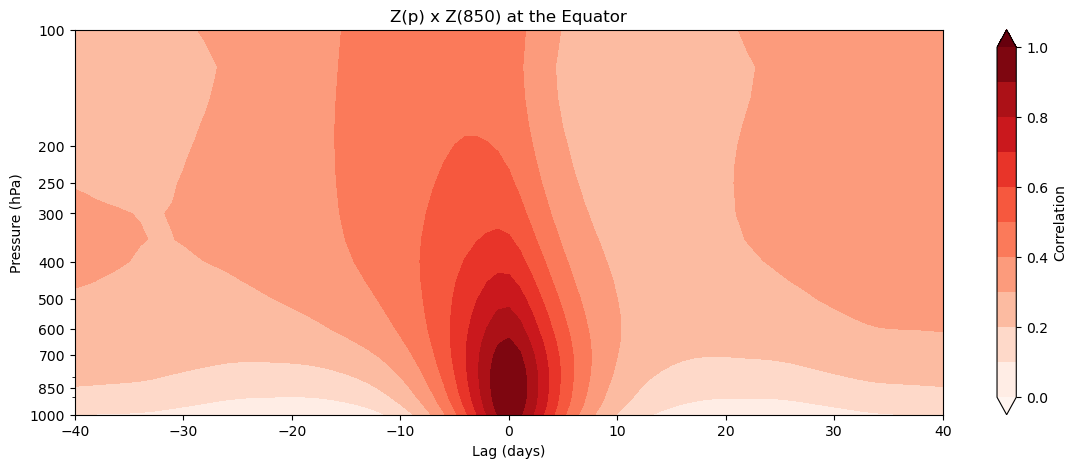

<Figure size 640x480 with 0 Axes>

In [15]:
pressure_levels = np.array([100., 200., 300, 400, 250,  500.,600, 700,  850., 1000.])

plt.figure(figsize=(14, 5)) # 8,4
cs = plt.contourf(
    lags, levels, correlations,
    levels=np.linspace(0,1,11), cmap="Reds", extend="both"
)
plt.gca().invert_yaxis()
plt.colorbar(cs, label="Correlation")
plt.yscale('log')
plt.gca().set_yticks(pressure_levels)
plt.gca().set_yticklabels([str(int(p)) for p in pressure_levels])
plt.gca().set_ylim(1000, 100)
plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=[], numticks=5))
plt.gca().set_yticks(pressure_levels)
plt.gca().set_yticklabels([str(int(p)) for p in pressure_levels])
plt.xlabel("Lag (days)")
plt.ylabel("Pressure (hPa)")
plt.title("Z(p) x Z(850) at the Equator")
plt.show()
plt.savefig('unfiltzpxz850.png', dpi=300, bbox_inches='tight') 

# 1 year highpass filtering (Butterworth)

In [13]:
cutoff_period = 365  
sampling_rate = 1    # samples per day
nyquist_freq = sampling_rate / 2

# Cutoff frequency (normalized to Nyquist) (why?)
cutoff_freq = (1/cutoff_period)/nyquist_freq

order = 4  # discuss later
b, a = butter(order, cutoff_freq, btype='high')

high_freq_vals = filtfilt(b, a, eqzmzd850ts)

high_freq = xr.DataArray(
    high_freq_vals,
    coords=eqzmzd850ts.coords,
    dims=eqzmzd850ts.dims,
    attrs=eqzmzd850ts.attrs  
)

low_freq = eqzmzd850ts - high_freq

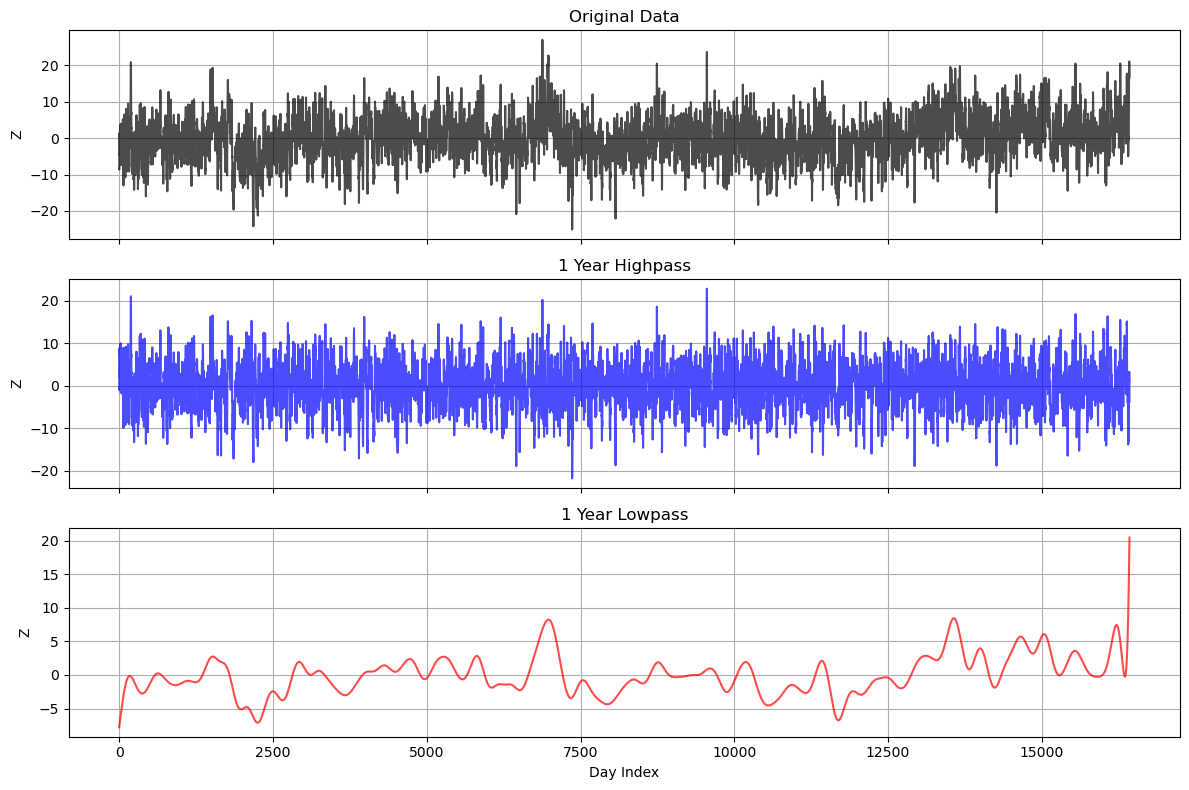

In [15]:
fig, ax = plt.subplots(3, 1, figsize=(12,8), sharex=True)

ax[0].plot(eqzmzd850ts.values, 'k-', alpha=0.7)
ax[0].set_ylabel('Z')
ax[0].set_title('Original Data')
ax[0].grid(True)

ax[1].plot(high_freq.values, 'b-', alpha=0.7)
ax[1].set_ylabel('Z')
ax[1].set_title('1 Year Highpass')
ax[1].grid(True)

ax[2].plot(low_freq.values, 'r-', alpha=0.7)
ax[2].set_ylabel('Z')
ax[2].set_title('1 Year Lowpass')
ax[2].grid(True)

plt.xlabel('Day Index')
plt.tight_layout()
plt.show()

In [42]:
# Let's look at one year
d2020 = eqzmzd850ts.sel(year=2020)
high_2020 = high_freq.sel(year=2020)
low_2020 = low_freq.sel(year=2020)

In [43]:
d2023 = eqzmzd850ts.sel(year=2023)
high_2023 = high_freq.sel(year=2023)
low_2023 = low_freq.sel(year=2023)

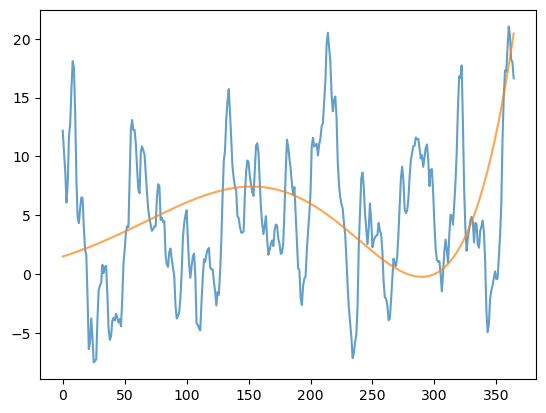

In [44]:
plt.plot(d2023.values, alpha = 0.7)
plt.plot(low_2023.values, alpha = 0.7)
plt.show()

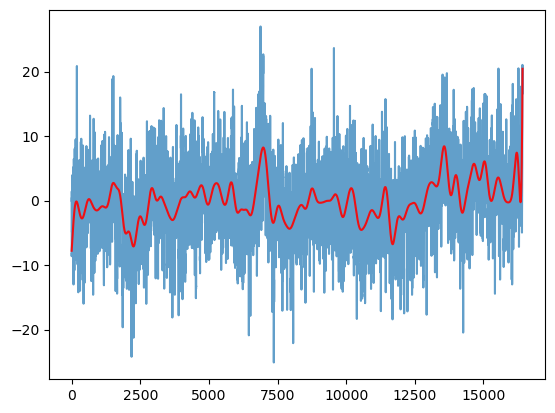

<Figure size 1500x800 with 0 Axes>

In [45]:
plt.plot(eqzmzd850ts.values, alpha=0.7)
plt.plot(low_freq.values, alpha=0.9, color='red')
plt.figure(figsize = (15,8))

plt.show()

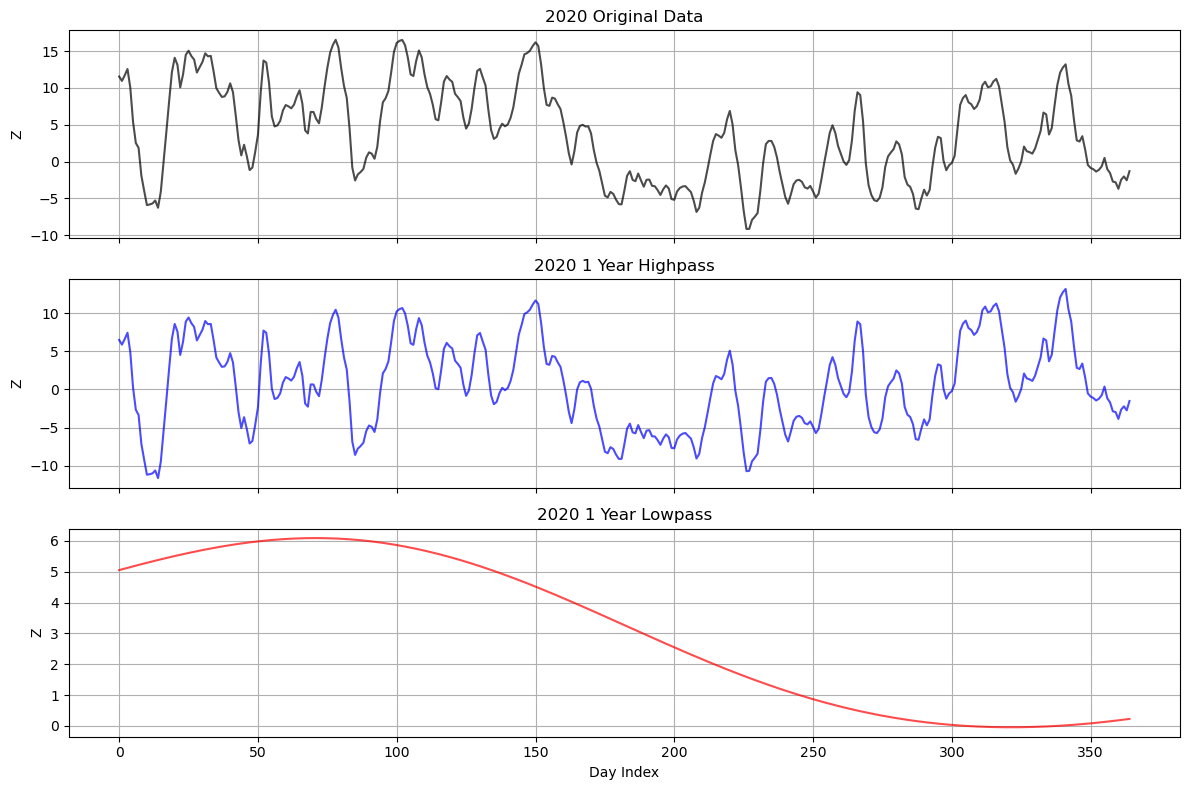

In [46]:
fig, ax = plt.subplots(3, 1, figsize=(12,8), sharex=True)

ax[0].plot(d2020.values, 'k-', alpha=0.7)
ax[0].set_ylabel('Z')
ax[0].set_title('2020 Original Data')
ax[0].grid(True)

ax[1].plot(high_2020.values, 'b-', alpha=0.7)
ax[1].set_ylabel('Z')
ax[1].set_title('2020 1 Year Highpass')
ax[1].grid(True)

ax[2].plot(low_2020.values, 'r-', alpha=0.7)
ax[2].set_ylabel('Z')
ax[2].set_title('2020 1 Year Lowpass')
ax[2].grid(True)

plt.xlabel('Day Index')
plt.tight_layout()
plt.show()

# Standardizing Functions and Testing Butterworth Filter Orders

In [14]:
highpzmza, lowpzmza = uf.butter1yhighp(eqzmzdanomts, 4)

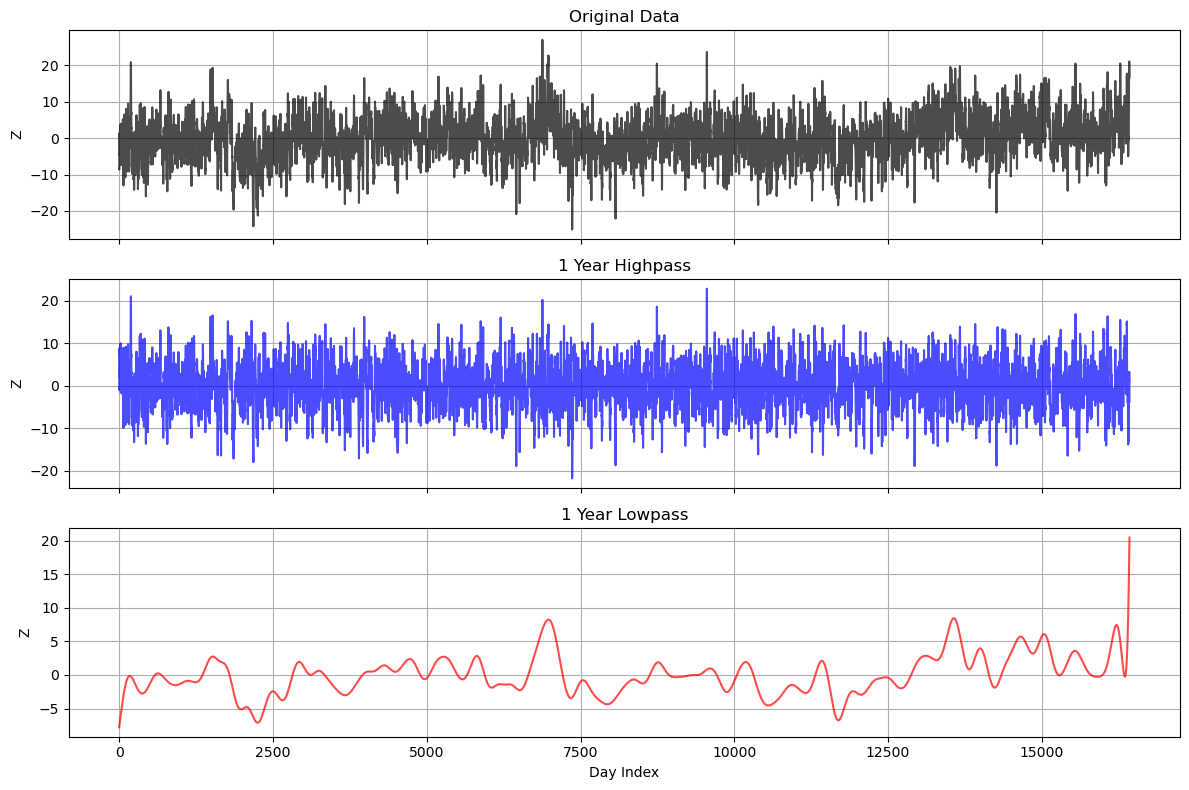

In [17]:
fig, ax = plt.subplots(3, 1, figsize=(12,8), sharex=True)

ax[0].plot(eqzmzdanomts.sel(level=850).values, 'k-', alpha=0.7)
ax[0].set_ylabel('Z')
ax[0].set_title('Original Data')
ax[0].grid(True)

ax[1].plot(highpzmza.sel(level=850).values, 'b-', alpha=0.7)
ax[1].set_ylabel('Z')
ax[1].set_title('1 Year Highpass')
ax[1].grid(True)

ax[2].plot(lowpzmza.sel(level=850).values, 'r-', alpha=0.7)
ax[2].set_ylabel('Z')
ax[2].set_title('1 Year Lowpass')
ax[2].grid(True)

plt.xlabel('Day Index')
plt.tight_layout()
plt.show()

In [15]:
zcorr = uf.level_lag_corr(highpzmza.sel(level=850), highpzmza)

In [19]:
zstd = highpzmza.std(dim='alltime')

In [20]:
zcov = zcorr*zstd

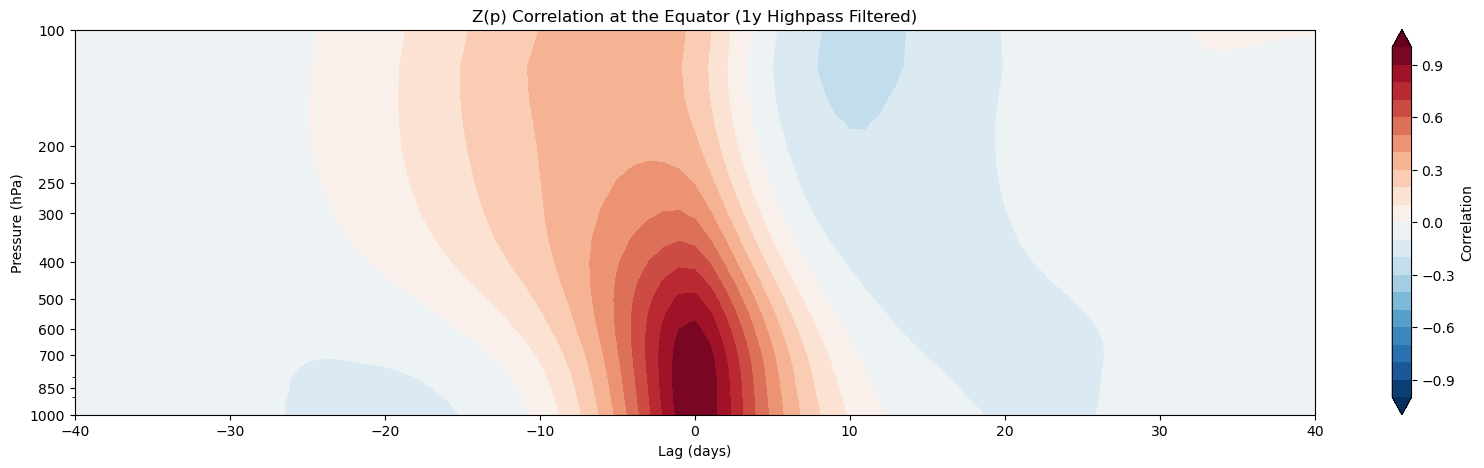

In [16]:
pressure_levels = np.array([100., 200., 300, 400, 250,  500.,600, 700,  850., 1000.])

plt.figure(figsize=(20, 5)) # 8,4
cs = plt.contourf(
    zcorr.lag, zcorr.level, zcorr.values,
    levels=np.linspace(-1,1,21), cmap="RdBu_r", extend="both",
    norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
)
plt.gca().invert_yaxis()
plt.colorbar(cs, label="Correlation")
plt.yscale('log')
plt.gca().set_yticks(pressure_levels)
plt.gca().set_yticklabels([str(int(p)) for p in pressure_levels])
plt.gca().set_ylim(1000, 100)
plt.gca().yaxis.set_major_locator(LogLocator(base=10.0, subs=[], numticks=5))
plt.gca().set_yticks(pressure_levels)
plt.gca().set_yticklabels([str(int(p)) for p in pressure_levels])
plt.xlabel("Lag (days)")
plt.ylabel("Pressure (hPa)")
plt.title("Z(p) Correlation at the Equator (1y Highpass Filtered)")
plt.savefig('filtzpxz850.png', dpi=300, bbox_inches='tight') 
plt.show()


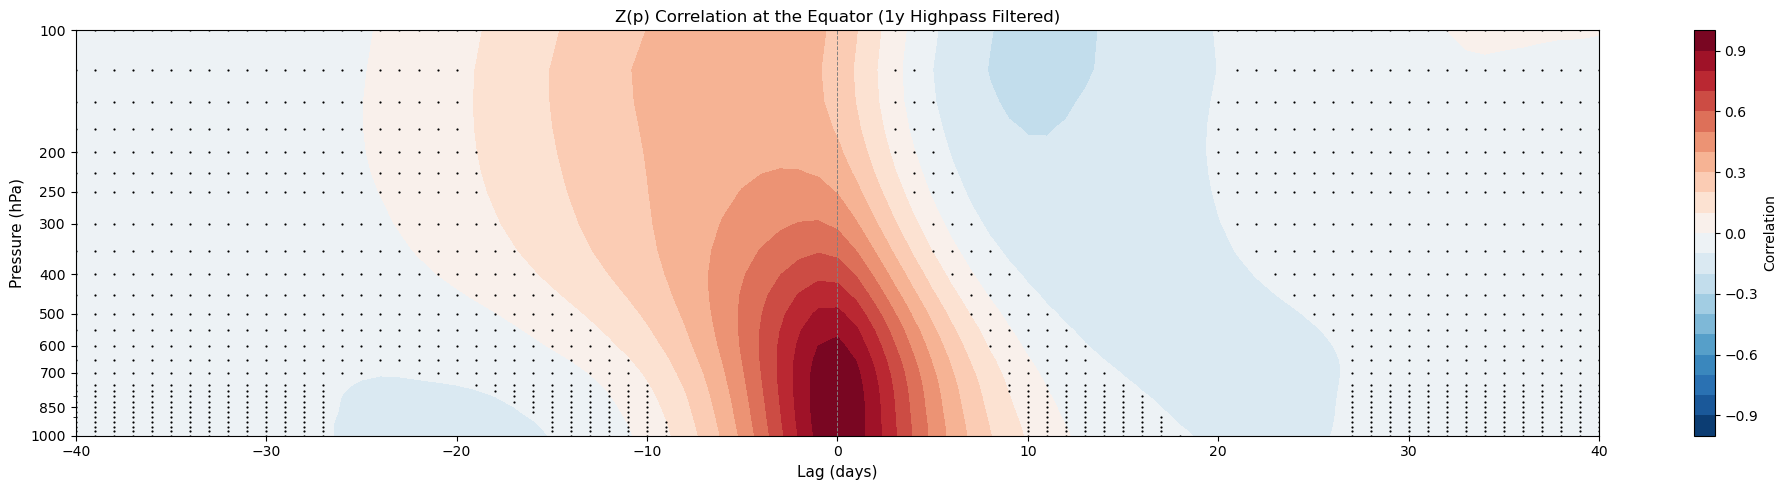

'\nfig, ax = plt.subplots(figsize=(12, 6))\ncf = plot_corr_with_significance(\n    ax, djfw300_corr, tau=40,\n    ylabel=\'Latitude (degrees)\'\n)\nax.set_title("W300 Correlation with TAM (DJF)")\nfig.colorbar(cf, ax=ax, label=\'Correlation\')\nplt.tight_layout()\nplt.show()\n\n# Precipitation (shorter decorrelation timescale)\nfig, ax = plt.subplots(figsize=(12, 6))\ncf = plot_corr_with_significance(\n    ax, precip_corr, tau=8,\n    ylabel=\'Latitude (degrees)\'\n)\nax.set_title("Precipitation Correlation with TAM")\nfig.colorbar(cf, ax=ax, label=\'Correlation\')\nplt.tight_layout()\nplt.show()\n'

In [26]:
def plot_corr_with_significance(ax, corr_da, tau, total_days=16059, alpha=0.05,
                                yscale='linear', invert_y=False,
                                yticks=None, yticklabels=None,
                                vmin=None, vmax=None, cmap='RdBu_r',
                                xlabel='Lag (days)', ylabel=''):
    """
    Generalized correlation plot with significance stippling.
    Works for any 2D corr DataArray with lag as one dimension.

    Parameters
    ----------
    ax           : matplotlib Axes
    corr_da      : xr.DataArray, dims (y_dim, lag)
    tau          : int -- decorrelation timescale in days (e.g. 40 for omega/GPH, 8 for precip)
    total_days   : int -- total days in dataset (default 16059)
    alpha        : float -- significance level (default 0.05)
    yscale       : 'linear' or 'log'
    invert_y     : bool -- True for pressure axis
    yticks       : array-like, optional explicit ticks
    yticklabels  : array-like, optional tick labels
    vmin/vmax    : floats, optional -- defaults to symmetric about 0
    cmap         : str, colormap (default 'RdBu_r')
    xlabel       : str
    ylabel       : str

    Returns
    -------
    cf : contourf object (for attaching colorbar externally)
    """
    N_eff = int(total_days / tau)

    lags = corr_da.lag.values
    # Infer y-dim as whichever dim is not lag
    y_dim = [d for d in corr_da.dims if d != 'lag'][0]
    y_vals = corr_da[y_dim].values

    # Symmetric norm by default
    if vmin is None or vmax is None:
        vmax = float(max(abs(corr_da.min()), abs(corr_da.max())))
        vmin = -vmax
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    levels = np.linspace(vmin, vmax, 21)

    # Correlation fill
    cf = ax.contourf(lags, y_vals, corr_da.values,
                     levels=levels, norm=norm, cmap=cmap)

    # Significance mask -- stipple where NOT significant
    sig_mask = compute_significance_mask(corr_da, N_eff, alpha=alpha)
    insig = ~sig_mask.values
    lag_grid, y_grid = np.meshgrid(lags, y_vals)
    ax.scatter(lag_grid[insig], y_grid[insig],
               s=10, c='black', marker='.', alpha=1, linewidths=0)

    # Axis formatting
    ax.set_yscale(yscale)
    if invert_y:
        ax.invert_yaxis()
    if yticks is not None:
        ax.set_yticks(yticks)
        if yticklabels is not None:
            ax.set_yticklabels(yticklabels)
    ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

    return cf


# --- Usage examples ---

# Pressure vs lag (e.g. Z(p) correlation)
fig, ax = plt.subplots(figsize=(20, 5))
cf = plot_corr_with_significance(
    ax, zcorr, tau=40,
    yscale='log', invert_y=True,
    yticks=pressure_levels,
    yticklabels=[str(int(p)) for p in pressure_levels],
    vmin=-1, vmax=1,
    ylabel='Pressure (hPa)'
)
ax.set_title("Z(p) Correlation at the Equator (1y Highpass Filtered)")
fig.colorbar(cf, ax=ax, label='Correlation')
plt.tight_layout()
plt.gca().set_ylim(1000, 100)
#plt.savefig('filtzpxz850.png', dpi=300, bbox_inches='tight')
plt.show()

# Latitude vs lag (e.g. W300 DJF)
"""
fig, ax = plt.subplots(figsize=(12, 6))
cf = plot_corr_with_significance(
    ax, djfw300_corr, tau=40,
    ylabel='Latitude (degrees)'
)
ax.set_title("W300 Correlation with TAM (DJF)")
fig.colorbar(cf, ax=ax, label='Correlation')
plt.tight_layout()
plt.show()

# Precipitation (shorter decorrelation timescale)
fig, ax = plt.subplots(figsize=(12, 6))
cf = plot_corr_with_significance(
    ax, precip_corr, tau=8,
    ylabel='Latitude (degrees)'
)
ax.set_title("Precipitation Correlation with TAM")
fig.colorbar(cf, ax=ax, label='Correlation')
plt.tight_layout()
plt.show()
"""

In [17]:
# ── Significance function ─────────────────────────────────────
def compute_significance_mask(corr_da, N_eff, alpha=0.05):
    """
    Pointwise two-sided t-test for correlation coefficients.
    Returns boolean mask, True where significant at (1-alpha) confidence.

    Parameters
    ----------
    corr_da : xr.DataArray (latitude, lag)
    N_eff   : int -- effective sample size (N_total / tau)
    alpha   : float -- significance level, default 0.05

    Returns
    -------
    xr.DataArray (bool), same dims as corr_da
    """
    r   = corr_da.values
    df  = N_eff - 2

    # Clip to avoid division by zero at r = ±1
    r_safe = np.clip(r, -0.9999, 0.9999)

    t_stat = r_safe * np.sqrt(df / (1 - r_safe**2))
    p_vals = 2 * stats.t.sf(np.abs(t_stat), df=df)

    return xr.DataArray(
        p_vals < alpha,
        coords=corr_da.coords,
        dims=corr_da.dims
    )


In [18]:
from scipy import stats

# ── N_eff values ──────────────────────────────────────────────
N_eff_full = int(16059 / 40)    # 401
N_eff_djf  = int(44 * 90 / 40)  # 99
N_eff_jja  = int(43 * 92 / 40)  # 98

for label, corr, N_eff in [('Full year', zcorr, N_eff_full)]:
    df     = N_eff - 2
    t_crit = stats.t.ppf(0.975, df=df)
    r_crit = np.sqrt(t_crit**2 / (t_crit**2 + df))
    r_max  = float(np.abs(corr).max())
    r_mean = float(np.abs(corr).mean())
    frac   = float(compute_significance_mask(corr, N_eff).values.mean()) * 100
    print(f"{label:<12}: r_crit={r_crit:.4f} | "
          f"|r| max={r_max:.4f} | |r| mean={r_mean:.4f} | "
          f"sig frac={frac:.1f}%")

Full year   : r_crit=0.0979 | |r| max=1.0000 | |r| mean=0.1252 | sig frac=35.2%


In [51]:
highpzmza1, lowpzmza1 = uf.butter1yhighp(eqzmzdanomts, 1)
highpzmza2, lowpzmza2 = uf.butter1yhighp(eqzmzdanomts, 2)
highpzmza4, lowpzmza4 = uf.butter1yhighp(eqzmzdanomts, 4)
highpzmza6, lowpzmza6 = uf.butter1yhighp(eqzmzdanomts, 6)
highpzmza8, lowpzmza8 = uf.butter1yhighp(eqzmzdanomts, 8)

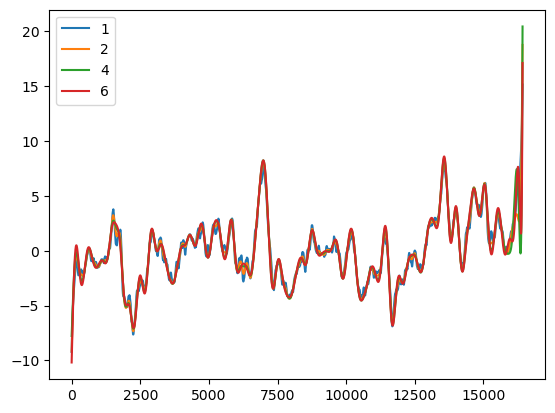

In [54]:
plt.plot(lowpzmza1.sel(level=850).values, label = '1')
plt.plot(lowpzmza2.sel(level=850).values, label = '2')
plt.plot(lowpzmza4.sel(level=850).values, label = '4')
plt.plot(lowpzmza6.sel(level=850).values, label = '6')
plt.legend()

In [56]:
edge_trim = 183

highpshaved = highpzmza4.isel(alltime=slice(edge_trim, -edge_trim))
lowpshaved = lowpzmza4.isel(alltime=slice(edge_trim, -edge_trim))

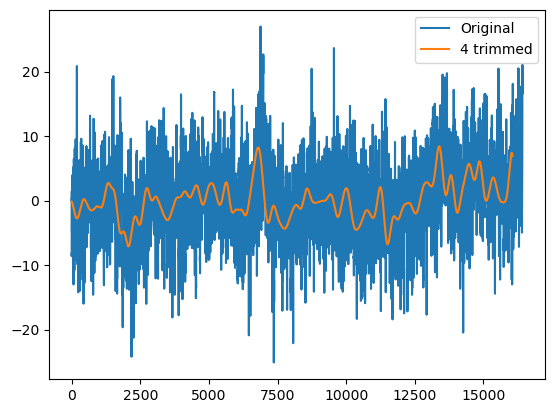

In [60]:
plt.plot(eqzmzdanomts.sel(level=850).values, label = 'Original')
plt.plot(lowpshaved.sel(level=850).values, label = '4 trimmed')

plt.legend()

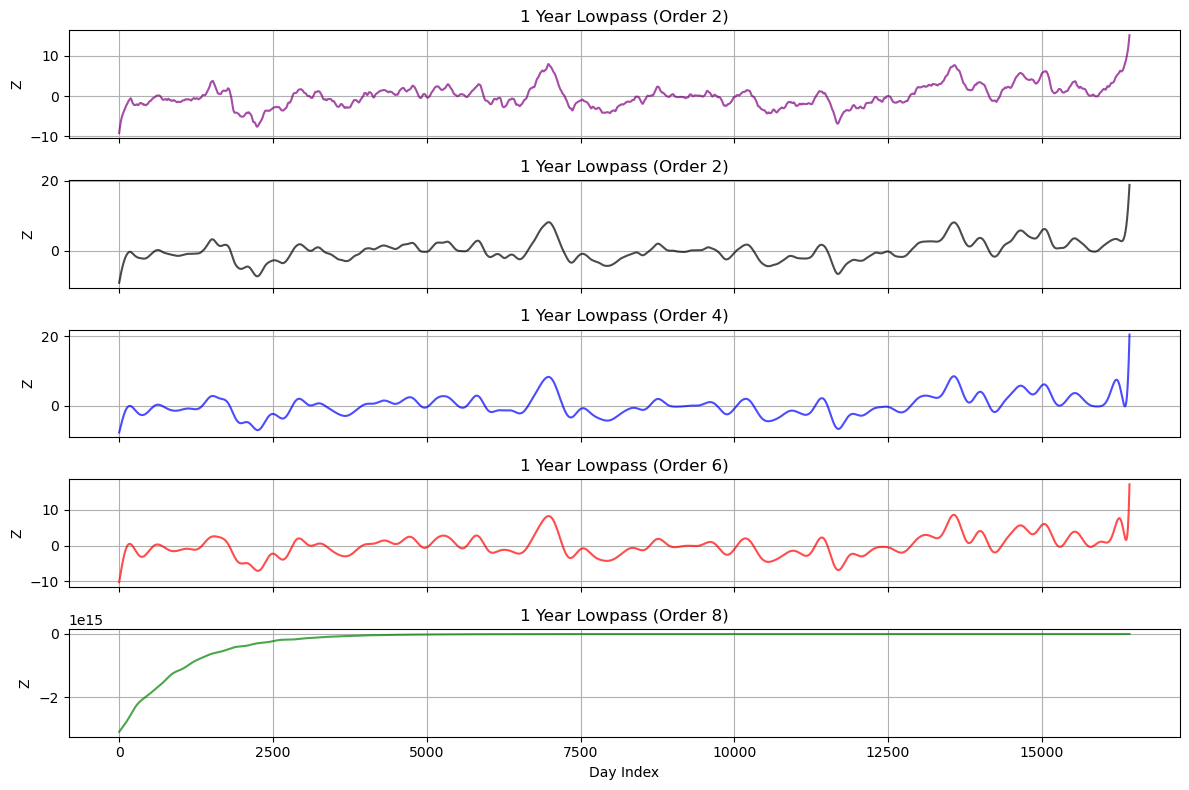

In [78]:
fig, ax = plt.subplots(5, 1, figsize=(12,8), sharex=True)

ax[0].plot(lowpzmza1.sel(level=850).values, color='purple', alpha=0.7)
ax[0].set_ylabel('Z')
ax[0].set_title('1 Year Lowpass (Order 2)')
ax[0].grid(True)

ax[1].plot(lowpzmza2.sel(level=850).values, 'k-', alpha=0.7)
ax[1].set_ylabel('Z')
ax[1].set_title('1 Year Lowpass (Order 4)')
ax[1].grid(True)

ax[2].plot(lowpzmza4.sel(level=850).values, 'b-', alpha=0.7)
ax[2].set_ylabel('Z')
ax[2].set_title('1 Year Lowpass (Order 8)')
ax[2].grid(True)

ax[3].plot(lowpzmza6.sel(level=850).values, 'r-', alpha=0.7)
ax[3].set_ylabel('Z')
ax[3].set_title('1 Year Lowpass (Order 12)')
ax[3].grid(True)

ax[4].plot(lowpzmza8.sel(level=850).values, 'g-', alpha=0.7)
ax[4].set_ylabel('Z')
ax[4].set_title('1 Year Lowpass (Order 16)')
ax[4].grid(True)

plt.xlabel('Day Index')
plt.tight_layout()
plt.show()